<a href="https://colab.research.google.com/github/danishbhi29/imdb_sentiment-analysis/blob/main/SentimentAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDb Sentiment Analysis

## Initial Setup and Library Imports

In [3]:
# Install necessary libraries
!pip install -q datasets tensorflow transformers nbdev
!pip install -q scikit-learn matplotlib numpy pandas nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.7/92.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.4/153.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 391.7/391.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 22.1 MB/s eta 0:00:00


In [11]:
# General Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords if not already present
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Scikit-learn Imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split

# TensorFlow/Keras Imports
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D, MultiHeadAttention, LayerNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Hugging Face Transformers Imports (TFAutoModelForSequenceClassification moved to BERT section)
from transformers import AutoTokenizer, AutoModelForSequenceClassification


# Set display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("All necessary libraries imported and NLTK stopwords downloaded.")

All necessary libraries imported and NLTK stopwords downloaded.


# Import Dataset of imdb using datasets laibrary by hugging **face**

### Loading IMDb Dataset

In [ ]:
!pip install datasets

## Data Loading and Initial Inspection

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

**Convert dataset to pandasdataframe**

### Converting to Pandas DataFrame

In [ ]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

**DATA EXPLORATION**

### Basic Data Overview

In [ ]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
train_df.shape
train_df.info()
train_df.isnull().sum()
train_df["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


,count
label,
0,12500
1,12500


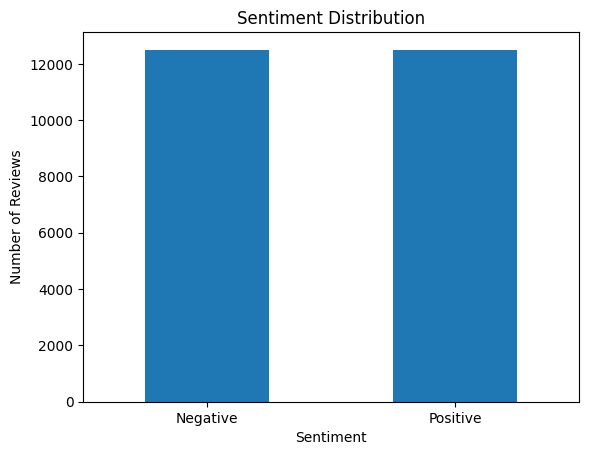

In [ ]:
import matplotlib.pyplot as plt

train_df['label'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1], ["Negative", "Positive"], rotation=0)
plt.show()

### Review Length Analysis

In [ ]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
train_df['word_count'].describe()

,word_count
count,25000.000000
mean,233.787200
std,173.733032
min,10.000000
25%,127.000000
50%,174.000000
75%,284.000000
max,2470.000000


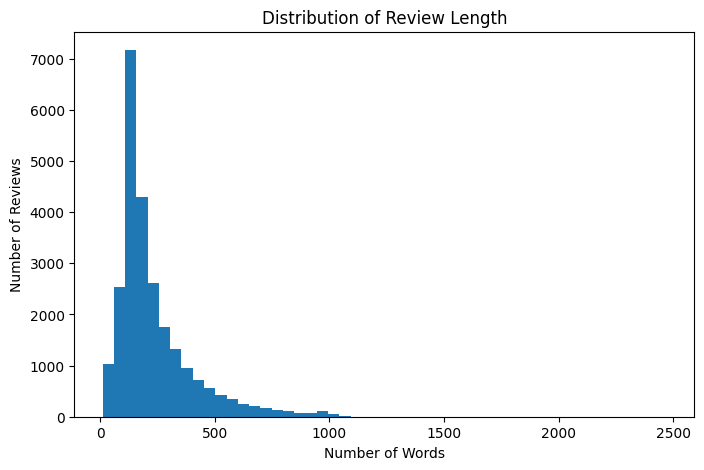

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(train_df['word_count'], bins=50)

plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
train_df.groupby('label')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,12500.0,230.86784,166.663126,10.0,128.0,174.0,278.0,1522.0
1,12500.0,236.70656,180.485743,12.0,125.0,174.0,291.0,2470.0


<Figure size 800x500 with 0 Axes>

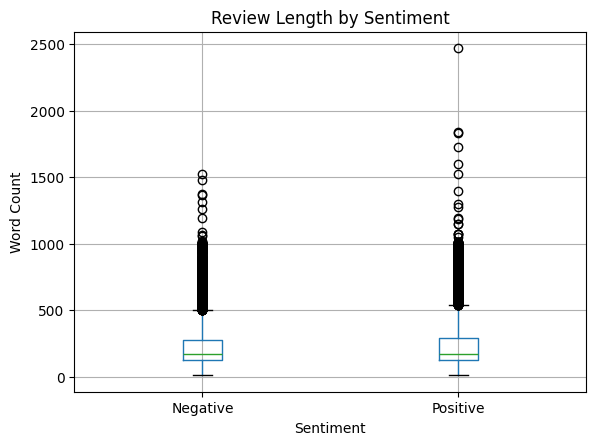

In [ ]:
plt.figure(figsize=(8,5))

train_df.boxplot(
    column='word_count',
    by='label'
)

plt.title("Review Length by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Word Count")
plt.xticks([1, 2], ["Negative", "Positive"])

plt.show()

**DATA PREPROCESSING**

## Text Preprocessing

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from collections import Counter

def get_common_words(texts):
    words = []

    for text in texts:
        words.extend(
            word.lower()
            for word in text.split()
            if word.lower() not in stop_words
        )

    return Counter(words)

### Stopword Removal and Common Word Analysis

In [ ]:
from collections import Counter

def get_common_words(texts):
    words = []

    for text in texts:
        words.extend(
            word.lower()
            for word in text.split()
            if word.lower() not in stop_words
        )

    return Counter(words)

In [ ]:
# Negative reviews
negative_words = get_common_words(
    train_df[train_df['label'] == 0]['text']
)

# Positive reviews
positive_words = get_common_words(
    train_df[train_df['label'] == 1]['text']
)


print("Top Negative Words:")
print(negative_words.most_common(20))

print("\nTop Positive Words:")
print(positive_words.most_common(20))

Top Negative Words:
[('/><br', 26318), ('movie', 17371), ('film', 13136), ('one', 10812), ('like', 10458), ('even', 7352), ('would', 6787), ('good', 5845), ('really', 5806), ('bad', 5335), ('see', 5010), ('get', 4851), ('-', 4652), ('much', 4524), ('could', 4487), ('make', 4454), ('people', 4017), ('time', 3955), ('made', 3800), ('first', 3790)]

Top Positive Words:
[('/><br', 24617), ('film', 14641), ('movie', 13516), ('one', 11668), ('like', 8321), ('good', 6081), ('great', 5504), ('see', 5400), ('really', 5259), ('would', 5240), ('story', 5033), ('also', 4975), ('-', 4703), ('even', 4658), ('much', 4215), ('first', 4195), ('get', 4108), ('time', 3990), ('well', 3803), ('best', 3733)]


In [ ]:
import re

def clean_for_eda(text):
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

### Text Cleaning Function

In [ ]:
train_df['eda_text'] = train_df['text'].apply(clean_for_eda)

In [ ]:
negative_words = get_common_words(
    train_df[train_df['label'] == 0]['eda_text']
)

positive_words = get_common_words(
    train_df[train_df['label'] == 1]['eda_text']
)

print("Top Negative Words:")
print(negative_words.most_common(20))

print("\nTop Positive Words:")
print(positive_words.most_common(20))

Top Negative Words:
[('movie', 24969), ('film', 19221), ('one', 13138), ('like', 11241), ('even', 7691), ('good', 7423), ('bad', 7401), ('would', 7036), ('really', 6263), ('time', 6211), ('see', 5452), ('story', 5210), ('much', 5078), ('get', 5040), ('people', 4807), ('make', 4722), ('could', 4686), ('made', 4541), ('first', 4307), ('well', 4257)]

Top Positive Words:
[('film', 20941), ('movie', 19078), ('one', 13657), ('like', 9040), ('good', 7724), ('story', 6780), ('time', 6516), ('great', 6419), ('well', 6411), ('see', 6027), ('also', 5551), ('really', 5476), ('would', 5400), ('even', 4965), ('first', 4757), ('much', 4688), ('people', 4480), ('best', 4320), ('love', 4302), ('get', 4272)]


In [ ]:
from nltk.util import ngrams

def get_bigrams(texts):
    bigrams = []

    for text in texts:
        words = text.split()
        bigrams.extend(ngrams(words, 2))

    return Counter(bigrams)

### Bigram Analysis

In [ ]:
negative_bigrams = get_bigrams(
    train_df[train_df['label'] == 0]['eda_text']
)

positive_bigrams = get_bigrams(
    train_df[train_df['label'] == 1]['eda_text']
)

In [ ]:
print("Top Negative Bigrams:")
print(negative_bigrams.most_common(20))

print("\nTop Positive Bigrams:")
print(positive_bigrams.most_common(20))

Top Negative Bigrams:
[(('of', 'the'), 17882), (('in', 'the'), 12274), (('this', 'movie'), 9002), (('it', 's'), 8654), (('to', 'be'), 6820), (('the', 'movie'), 6654), (('the', 'film'), 6300), (('and', 'the'), 6073), (('this', 'film'), 5524), (('to', 'the'), 5446), (('don', 't'), 5185), (('is', 'a'), 5150), (('it', 'was'), 4560), (('on', 'the'), 4425), (('in', 'a'), 4274), (('this', 'is'), 4274), (('it', 'is'), 4192), (('for', 'the'), 3966), (('of', 'a'), 3815), (('with', 'the'), 3720)]

Top Positive Bigrams:
[(('of', 'the'), 21328), (('in', 'the'), 13082), (('it', 's'), 8626), (('is', 'a'), 7982), (('the', 'film'), 7291), (('and', 'the'), 7279), (('this', 'movie'), 6730), (('to', 'the'), 6567), (('it', 'is'), 5945), (('this', 'film'), 5421), (('the', 'movie'), 5243), (('this', 'is'), 5207), (('to', 'be'), 5063), (('one', 'of'), 4810), (('in', 'a'), 4646), (('on', 'the'), 4590), (('with', 'the'), 4183), (('for', 'the'), 4054), (('of', 'a'), 4027), (('it', 'was'), 3979)]


In [ ]:
def get_meaningful_bigrams(texts):
    bigrams = []

    for text in texts:
        words = [
            word for word in text.split()
            if word not in stop_words
        ]

        bigrams.extend(ngrams(words, 2))

    return Counter(bigrams)

In [ ]:
negative_bigrams = get_meaningful_bigrams(
    train_df[train_df['label'] == 0]['eda_text']
)

positive_bigrams = get_meaningful_bigrams(
    train_df[train_df['label'] == 1]['eda_text']
)

In [ ]:
print("Top Negative Bigrams:")
print(negative_bigrams.most_common(20))

print("\nTop Positive Bigrams:")
print(positive_bigrams.most_common(20))

Top Negative Bigrams:
[(('ever', 'seen'), 831), (('waste', 'time'), 751), (('special', 'effects'), 687), (('looks', 'like'), 627), (('low', 'budget'), 595), (('year', 'old'), 507), (('much', 'better'), 502), (('one', 'worst'), 485), (('even', 'though'), 466), (('movie', 'ever'), 465), (('bad', 'movie'), 447), (('look', 'like'), 435), (('see', 'movie'), 386), (('pretty', 'much'), 370), (('watch', 'movie'), 367), (('worst', 'movie'), 365), (('really', 'bad'), 362), (('main', 'character'), 356), (('bad', 'acting'), 356), (('good', 'movie'), 348)]

Top Positive Bigrams:
[(('one', 'best'), 799), (('even', 'though'), 577), (('first', 'time'), 500), (('ever', 'seen'), 490), (('new', 'york'), 485), (('special', 'effects'), 427), (('see', 'movie'), 386), (('real', 'life'), 383), (('years', 'ago'), 380), (('must', 'see'), 378), (('good', 'movie'), 371), (('year', 'old'), 371), (('well', 'done'), 369), (('sci', 'fi'), 336), (('great', 'movie'), 333), (('pretty', 'good'), 304), (('watch', 'movie')

### TF-IDF Vectorization for Feature Engineering

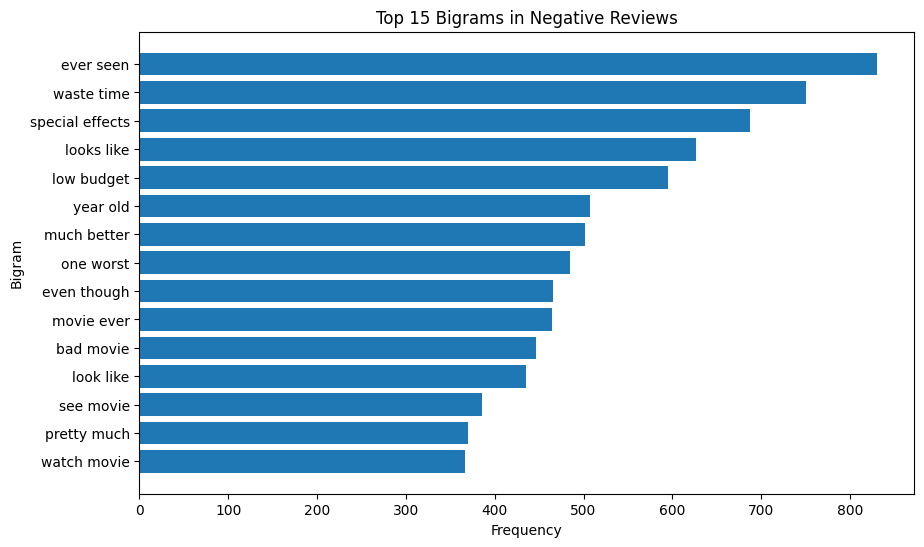

In [ ]:
top_negative = negative_bigrams.most_common(15)

labels = [' '.join(words) for words, count in top_negative]
values = [count for words, count in top_negative]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1])

plt.title("Top 15 Bigrams in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Bigram")

plt.show()

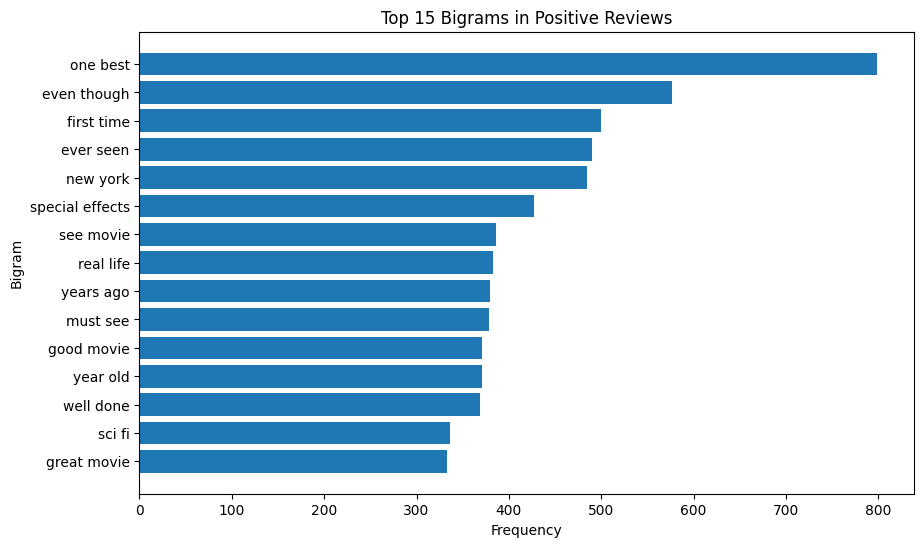

In [ ]:
top_positive = positive_bigrams.most_common(15)

labels = [' '.join(words) for words, count in top_positive]
values = [count for words, count in top_positive]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1])

plt.title("Top 15 Bigrams in Positive Reviews")
plt.xlabel("Frequency")
plt.ylabel("Bigram")

plt.show()

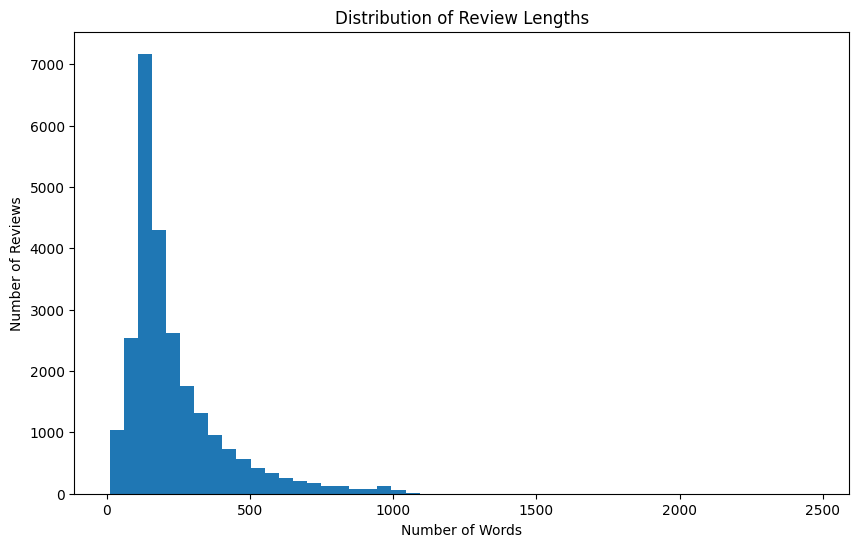

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(train_df['word_count'], bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

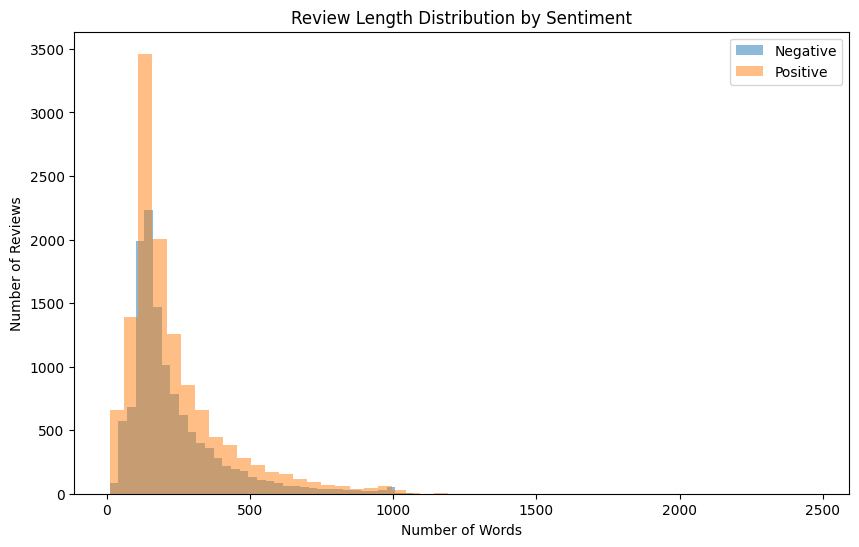

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_df[train_df['label'] == 0]['word_count'],
    bins=50,
    alpha=0.5,
    label='Negative'
)

plt.hist(
    train_df[train_df['label'] == 1]['word_count'],
    bins=50,
    alpha=0.5,
    label='Positive'
)

plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.legend()

plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(train_df['eda_text'])
y = train_df['label']

print(X_tfidf.shape)

(25000, 5000)


In [ ]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:20])
print("Total features:", len(feature_names))

['abandoned' 'abc' 'abilities' 'ability' 'able' 'abraham' 'absence'
 'absent' 'absolute' 'absolutely' 'absurd' 'absurdity' 'abuse' 'abused'
 'abusive' 'abysmal' 'academy' 'accent' 'accents' 'accept']
Total features: 5000


In [ ]:
negative_idx = train_df['label'].values == 0
positive_idx = train_df['label'].values == 1

In [ ]:
negative_scores = np.asarray(
    X_tfidf[negative_idx].mean(axis=0)
).ravel()

positive_scores = np.asarray(
    X_tfidf[positive_idx].mean(axis=0)
).ravel()

negative_top = negative_scores.argsort()[-20:][::-1]

for i in negative_top:
    print(feature_names[i], round(negative_scores[i], 4))

movie 0.0677
film 0.0494
bad 0.0329
just 0.0325
like 0.0321
good 0.0253
really 0.0231
don 0.0218
time 0.0216
acting 0.0192
story 0.0192
plot 0.0192
movies 0.0188
make 0.0186
people 0.0185
watch 0.0165
worst 0.0163
better 0.0159
think 0.0156
did 0.0156


In [ ]:
positive_top = positive_scores.argsort()[-20:][::-1]

for i in positive_top:
    print(feature_names[i], round(positive_scores[i], 4))

movie 0.0521
film 0.0516
great 0.0267
good 0.0257
like 0.0252
story 0.0237
just 0.0212
time 0.0209
really 0.0198
love 0.0192
best 0.0187
people 0.0172
life 0.0168
movies 0.016
think 0.0157
watch 0.0156
films 0.0152
seen 0.0152
way 0.0149
characters 0.0144


In [ ]:
difference = positive_scores - negative_scores

top_positive = difference.argsort()[-20:][::-1]

print("Most Positive-associated words:\n")

for i in top_positive:
    print(feature_names[i], round(difference[i], 4))

Most Positive-associated words:

great 0.016
love 0.01
best 0.0097
excellent 0.0086
wonderful 0.0076
life 0.0063
beautiful 0.0057
loved 0.0057
perfect 0.0057
amazing 0.0057
favorite 0.0051
family 0.0049
world 0.0049
brilliant 0.0045
performance 0.0045
story 0.0045
series 0.0044
young 0.0044
fun 0.0043
highly 0.0043


In [ ]:
top_negative = difference.argsort()[:20]

print("Most Negative-associated words:\n")

for i in top_negative:
    print(feature_names[i], round(difference[i], 4))

Most Negative-associated words:

bad -0.0253
movie -0.0156
worst -0.015
just -0.0113
waste -0.0105
awful -0.01
plot -0.009
terrible -0.0088
boring -0.0083
acting -0.0083
don -0.008
stupid -0.0079
minutes -0.0078
worse -0.0076
horrible -0.0072
poor -0.0071
script -0.007
money -0.007
like -0.0069
make -0.0065


In [ ]:
X_train_text = train_df['eda_text']
y_train = train_df['label']

X_test_text = test_df['text'].apply(clean_for_eda)
y_test = test_df['label']

print("Training:", len(X_train_text))
print("Testing:", len(X_test_text))

Training: 25000
Testing: 25000


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (25000, 5000)
X_test: (25000, 5000)


## NLP using Machine Learning

# **Model Training**

### Logistic Regression Model Training

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


# **Model Evaluation**

### Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print("Predicted:", y_pred[:20])
print("Actual:   ", y_test.values[:20])

Predicted: [0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual:    [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.8797
Precision: 0.8759
Recall   : 0.8848
F1 Score : 0.8803


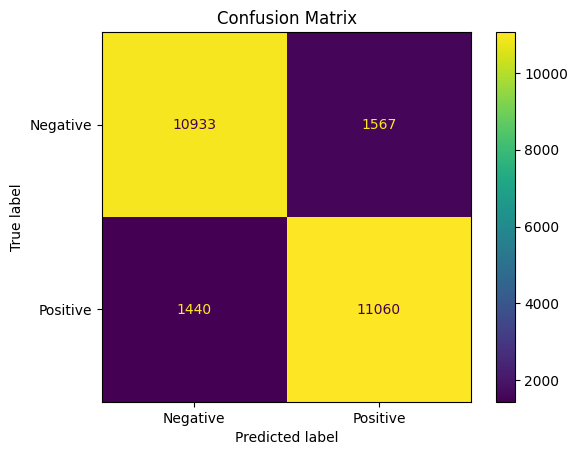

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
review = "The movie had a promising beginning and some genuinely impressive performances, but the story became predictable halfway through. The visuals were beautiful, yet the dialogue felt forced and the ending was disappointing. Overall, I enjoyed parts of it, but I wouldn't recommend it."

# Same preprocessing
cleaned_review = clean_for_eda(review)

# TF-IDF
review_tfidf = tfidf.transform([cleaned_review])

# Prediction
prediction = model.predict(review_tfidf)[0]

if prediction == 1:
    print("Sentiment: Positive 😊")
else:
    print("Sentiment: Negative 😞")

probability = model.predict_proba(review_tfidf)[0]

print("Negative probability:", round(probability[0], 4))
print("Positive probability:", round(probability[1], 4))

Sentiment: Positive 😊
Negative probability: 0.4817
Positive probability: 0.5183


In [ ]:
probability = model.predict_proba(review_tfidf)[0]

print("Negative probability:", round(probability[0], 4))
print("Positive probability:", round(probability[1], 4))

Negative probability: 0.0023
Positive probability: 0.9977


# **TRY multiple MACHINE LEARNING MODELS TO FIND BEST PERFROMER ON MY DATA**

### Comparing Multiple ML Models

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "SGD Classifier": SGDClassifier(random_state=42)
}

results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_pred_model = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "Precision": precision_score(y_test, y_pred_model),
        "Recall": recall_score(y_test, y_pred_model),
        "F1 Score": f1_score(y_test, y_pred_model)
    })

print("\nAll models trained!")

Training Logistic Regression...
Training Naive Bayes...
Training Linear SVM...
Training SGD Classifier...

All models trained!


# **BEST PERFORMING MODEL**

### Hyperparameter Tuning for Best ML Model

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.87972,0.875901,0.88480,0.880328
3,SGD Classifier,0.87472,0.868761,0.88280,0.875724
2,Linear SVM,0.86024,0.864144,0.85488,0.859487
1,Naive Bayes,0.83988,0.852251,0.82232,0.837018


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    lr,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best C: {'C': 1}
Best CV F1: 0.8594912185474325


In [ ]:
best_model = LogisticRegression(C=1, max_iter=1000)

best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

Accuracy : 0.87972
Precision: 0.8759008473905124
Recall   : 0.8848
F1 Score : 0.8803279340947984


In [ ]:
!pip install tensorflow

## NLP using Deep Learning

# **NLP using Deep Learning**

# **NLP USING ANN**

### Artificial Neural Network (ANN)

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
X_train_nn = X_train.toarray()
X_test_nn = X_test.toarray()

print(X_train_nn.shape)
print(X_test_nn.shape)

(25000, 5000)
(25000, 5000)


In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model = Sequential([
    Input(shape=(5000,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,449 (2.47 MB)

 Trainable params: 648,449 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_nn,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.8265 - loss: 0.3716 - val_accuracy: 0.8120 - val_loss: 0.4526
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9208 - loss: 0.2067 - val_accuracy: 0.7812 - val_loss: 0.5489
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9456 - loss: 0.1498 - val_accuracy: 0.7258 - val_loss: 0.7810
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9689 - loss: 0.0954 - val_accuracy: 0.7068 - val_loss: 0.9872
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9859 - loss: 0.0492 - val_accuracy: 0.7254 - val_loss: 1.1568
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9944 - loss: 0.0218 - val_accuracy: 0.7124 - val_loss: 1.4596
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9980 - loss: 0.0096 - val_accuracy: 0.7486 - val_loss: 1.4830
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9990 - loss: 0.0056 - val_acc

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_nn,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 1.0414589643478394
Test Accuracy: 0.8389999866485596


In [ ]:
X_train_text = train_df['text']
y_train = train_df['label']

X_test_text = test_df['text']
y_test = test_df['label']

print(X_train_text.shape)
print(X_test_text.shape)

(25000,)
(25000,)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

print(X_train_seq[0][:20])

[10, 1605, 10, 241, 1992, 4174, 36, 58, 371, 1127, 85, 4, 29, 1, 7093, 12, 3383, 9, 51, 9]


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=300,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=300,
    padding='post',
    truncating='post'
)

print(X_train_pad.shape)
print(X_test_pad.shape)

(25000, 300)
(25000, 300)


# **NLP USING LSTM**

### Long Short-Term Memory (LSTM)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Embedding(
        input_dim=20000,
        output_dim=128,
        input_length=300
    ),

    LSTM(64),

    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model_lstm.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

model_lstm = Sequential([
    Input(shape=(300,)),

    Embedding(
        input_dim=20000,
        output_dim=128
    ),

    LSTM(64),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,609,473 (9.95 MB)

 Trainable params: 2,609,473 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=45,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/45
313/313 ━━━━━━━━━━━━━━━━━━━━ 130s 415ms/step - accuracy: 0.9441 - loss: 0.1720 - val_accuracy: 0.7248 - val_loss: 0.7254
Epoch 2/45
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 390ms/step - accuracy: 0.9699 - loss: 0.1026 - val_accuracy: 0.7458 - val_loss: 0.9568
Epoch 3/45
313/313 ━━━━━━━━━━━━━━━━━━━━ 124s 398ms/step - accuracy: 0.9753 - loss: 0.0827 - val_accuracy: 0.7226 - val_loss: 1.0858
Epoch 4/45
313/313 ━━━━━━━━━━━━━━━━━━━━ 123s 392ms/step - accuracy: 0.9884 - loss: 0.0458 - val_accuracy: 0.6374 - val_loss: 1.5055
Epoch 5/45
313/313 ━━━━━━━━━━━━━━━━━━━━ 121s 386ms/step - accuracy: 0.9849 - loss: 0.0519 - val_accuracy: 0.7186 - val_loss: 0.9508
Epoch 6/45
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 391ms/step - accuracy: 0.9916 - loss: 0.0331 - val_accuracy: 0.7390 - val_loss: 1.1857
Epoch 7/45
313/313 ━━━━━━━━━━━━━━━━━━━━ 121s 384ms/step - accuracy: 0.9952 - loss: 0.0218 - val_accuracy: 0.6752 - val_loss: 1.5389
Epoch 8/45
313/313 ━━━━━━━━━━━━━━━━━━━━ 120s 382ms/step - accuracy: 0.9976 -

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

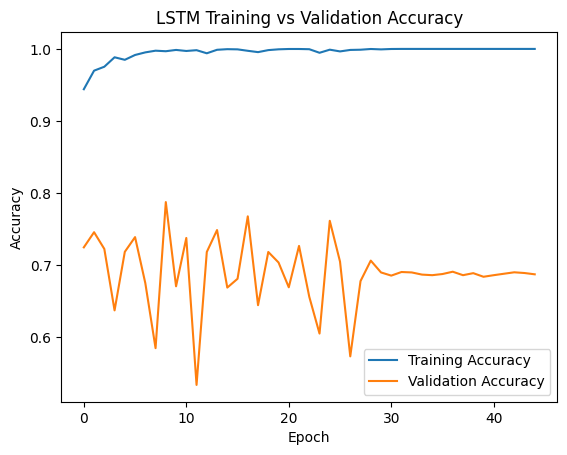

In [ ]:
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('LSTM Training vs Validation Accuracy')
plt.legend()
plt.show()

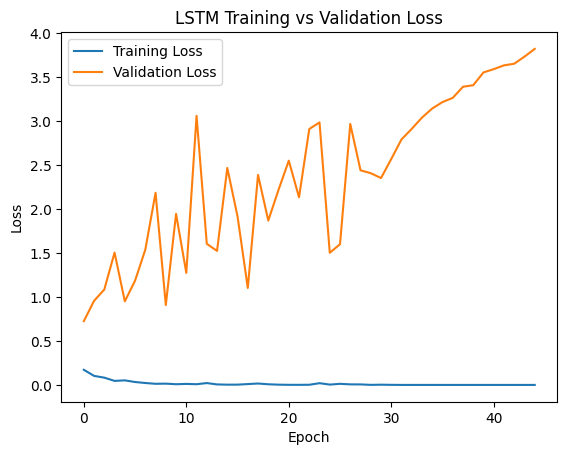

In [ ]:
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# **NLP USING TRANSFORMER ENCODER**

### Transformer Encoder (Custom Implementation)

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

In [ ]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization

class TransformerBlock(tf.keras.layers.Layer):

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()

        self.attention = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.ffn = Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim)
        ])

        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)

        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):

        # Self-Attention
        attention_output = self.attention(inputs, inputs)

        attention_output = self.dropout1(
            attention_output,
            training=training
        )

        out1 = self.norm1(inputs + attention_output)

        # Feed Forward Network
        ffn_output = self.ffn(out1)

        ffn_output = self.dropout2(
            ffn_output,
            training=training
        )

        return self.norm2(out1 + ffn_output)

In [ ]:
embed_dim = 64
num_heads = 2
ff_dim = 128

model_transformer = Sequential([
    Input(shape=(300,)),

    Embedding(
        input_dim=20000,
        output_dim=embed_dim
    ),

    TransformerBlock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim
    ),

    GlobalAveragePooling1D(),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model_transformer.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 300, 64)        │        50,048 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,334,273 (5.09 MB)

 Trainable params: 1,334,273 (5.09 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_transformer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_transformer = model_transformer.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 297s 922ms/step - accuracy: 0.7782 - loss: 0.4490 - val_accuracy: 0.8406 - val_loss: 0.3911
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 283s 905ms/step - accuracy: 0.9295 - loss: 0.1904 - val_accuracy: 0.6586 - val_loss: 1.0158
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 324s 911ms/step - accuracy: 0.9639 - loss: 0.1077 - val_accuracy: 0.6880 - val_loss: 0.9998
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 339s 967ms/step - accuracy: 0.9819 - loss: 0.0592 - val_accuracy: 0.7332 - val_loss: 0.9807
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 304s 971ms/step - accuracy: 0.9912 - loss: 0.0321 - val_accuracy: 0.6522 - val_loss: 1.6905


In [ ]:
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_pad,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train_new.shape)
print("Validation:", X_val.shape)

Train: (20000, 300)
Validation: (5000, 300)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
history_transformer = model_transformer.fit(
    X_train_new,
    y_train_new,

    validation_data=(X_val, y_val),

    epochs=8,
    batch_size=64,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 291s 927ms/step - accuracy: 0.9480 - loss: 0.1514 - val_accuracy: 0.9538 - val_loss: 0.1286
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 317s 915ms/step - accuracy: 0.9790 - loss: 0.0720 - val_accuracy: 0.9470 - val_loss: 0.1506
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 320s 908ms/step - accuracy: 0.9894 - loss: 0.0411 - val_accuracy: 0.9402 - val_loss: 0.2178


In [ ]:
test_loss, test_accuracy = model_transformer.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 114s 145ms/step - accuracy: 0.8462 - loss: 0.4598
Test Accuracy: 0.8461999893188477
